# Week 11 — independent contour-aware preservation analysis

This notebook is a **post-hoc evaluation notebook** for the saved dSprites Week-11 runs.

It does **not retrain** the VAE or the heads. It only:

1. resolves the saved run folders from the provided archives/directories,
2. reloads the saved checkpoints,
3. rebuilds the exact ID / OOD dSprites splits for each matched run,
4. evaluates the **selected** fixed-step and auto-step operating points,
5. computes **independent geometric preservation metrics** on reconstruction → steered pairs,
6. aggregates **mean ± std** across the 5 global runs and the 5 local runs.

Main new metrics:
- normalized contour Chamfer distance ↓
- principal-axis orientation drift (deg) ↓
- centroid drift (px) ↓
- topology break rate ↓

The notebook is intentionally **linear**. Fill the TODO paths in the config cell and run top to bottom.

In [1]:

DSPRITES_NPZ_PATH = "../week10/dsprites_ndarray_co1sh3sc6or40x32y32_64x64.npz"

# Put here the archives or extracted roots that contain the saved Week-11 run folders.
# Both .zip files and extracted directories are supported.
RUN_SOURCES = [
    "global.zip",
    "local.zip",
]

OUTPUT_ROOT = "./week11_independent_preservation_outputs"
DEVICE_NAME = "cpu"   # change to "cpu" if needed
BATCH_SIZE_OVERRIDE = None   # None = use saved batch size from each run config
FORCE_RECOMPUTE = False

THRESHOLD = 0.5
MAX_CONTOUR_POINTS = 256
PREVIEW_ROWS_PER_GROUP = 8

# Keep these unless you intentionally changed the matched rerun set.
SEED_SCHEDULE = [7, 11, 17, 23, 31]

WEEK11_GLOBAL_RUN_IDS = [
    "20260401_204921_week10_dsprites_ood_only",
    "20260401_211446_week10_dsprites_ood_only",
    "20260401_214018_week10_dsprites_ood_only",
    "20260401_220548_week10_dsprites_ood_only",
    "20260401_223111_week10_dsprites_ood_only",
]

WEEK11_LOCAL_RUN_IDS = [
    "20260331_035529_week10_dsprites_ood_local_knn",
    "20260331_042059_week10_dsprites_ood_local_knn",
    "20260331_044627_week10_dsprites_ood_local_knn",
    "20260331_051153_week10_dsprites_ood_local_knn",
    "20260331_053721_week10_dsprites_ood_local_knn",
]

In [2]:
# =========================
# Imports
# =========================

import io
import json
import math
import random
import shutil
import zipfile
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm
from IPython.display import display

from scipy import ndimage as ndi
from scipy.spatial import cKDTree

print("torch:", torch.__version__)
print("numpy:", np.__version__)
print("pandas:", pd.__version__)

C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


torch: 2.10.0+cpu
numpy: 2.4.2
pandas: 3.0.1


In [3]:
# =========================
# Helpers + dataset + models
# =========================

def get_device(name: str) -> torch.device:
    if name == "cuda" and torch.cuda.is_available():
        return torch.device("cuda")
    return torch.device("cpu")


def require_manual_path(value: str, label: str) -> str:
    value = str(value).strip()
    if value == "" or value.upper().startswith("TODO"):
        raise ValueError(f"Fill the TODO path for {label} before running the notebook.")
    path = Path(value).expanduser().resolve()
    if not path.exists():
        raise FileNotFoundError(f"Path for {label} does not exist: {path}")
    return str(path)


def ensure_dir(path: str | Path) -> Path:
    path = Path(path)
    path.mkdir(parents=True, exist_ok=True)
    return path


def normalize_direction(v: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    v = np.asarray(v, dtype=np.float32)
    n = float(np.linalg.norm(v))
    return v / max(n, eps)


def encode_mu(model: nn.Module, x: torch.Tensor) -> torch.Tensor:
    mu, _ = model.enc(x)
    return mu


def decode_sigmoid(model: nn.Module, z: torch.Tensor) -> torch.Tensor:
    return torch.sigmoid(model.dec(z))


def load_checkpoint_state(model: nn.Module, checkpoint_path: str, device: torch.device) -> nn.Module:
    payload = torch.load(checkpoint_path, map_location=device)
    state = payload["model"] if isinstance(payload, dict) and "model" in payload else payload
    model.load_state_dict(state)
    return model


class DSpritesSubset(Dataset):
    def __init__(self, npz_path: str, indices: np.ndarray):
        data = np.load(npz_path, allow_pickle=True, mmap_mode="r")
        self.imgs = data["imgs"]
        self.classes = data["latents_classes"]
        self.indices = np.asarray(indices, dtype=np.int64)

    def __len__(self) -> int:
        return len(self.indices)

    def __getitem__(self, i: int):
        idx = int(self.indices[i])
        x = self.imgs[idx].astype(np.float32)[None, ...]
        c = self.classes[idx].astype(np.int64)
        return torch.from_numpy(x), torch.from_numpy(c)


def build_group_splits(
    npz_path: str,
    train_orientations: List[int],
    ood_orientations: List[int],
    train_groups: int,
    val_groups: int,
    id_test_groups: int,
    ood_test_groups: int,
    seed: int,
) -> Dict[str, np.ndarray]:

    data = np.load(npz_path, allow_pickle=True, mmap_mode="r")
    classes = np.asarray(data["latents_classes"], dtype=np.int64)

    # factor order: color, shape, scale, orientation, posX, posY
    group_factors = classes[:, [1, 3, 4, 5]]   # shape, orientation, posX, posY
    uniq_groups, inverse = np.unique(group_factors, axis=0, return_inverse=True)

    train_mask = np.isin(uniq_groups[:, 1], np.asarray(train_orientations, dtype=np.int64))
    ood_mask = np.isin(uniq_groups[:, 1], np.asarray(ood_orientations, dtype=np.int64))

    train_pool = np.where(train_mask)[0]
    ood_pool = np.where(ood_mask)[0]

    rng = np.random.default_rng(seed)
    rng.shuffle(train_pool)
    rng.shuffle(ood_pool)

    need_train = int(train_groups) + int(val_groups) + int(id_test_groups)
    if need_train > len(train_pool):
        raise ValueError(f"Requested {need_train} ID groups, but only {len(train_pool)} are available.")
    if int(ood_test_groups) > len(ood_pool):
        raise ValueError(f"Requested {ood_test_groups} OOD groups, but only {len(ood_pool)} are available.")

    g_train = train_pool[: int(train_groups)]
    g_val = train_pool[int(train_groups): int(train_groups) + int(val_groups)]
    g_id_test = train_pool[int(train_groups) + int(val_groups): need_train]
    g_ood_test = ood_pool[: int(ood_test_groups)]

    def group_ids_to_indices(group_ids: np.ndarray) -> np.ndarray:
        return np.where(np.isin(inverse, group_ids))[0].astype(np.int64)

    return {
        "train_idx": group_ids_to_indices(g_train),
        "val_idx": group_ids_to_indices(g_val),
        "id_test_idx": group_ids_to_indices(g_id_test),
        "ood_test_idx": group_ids_to_indices(g_ood_test),
    }


class ResidualBlock(nn.Module):
    def __init__(self, channels: int, groups: int = 8):
        super().__init__()
        g = max(1, min(groups, channels))
        while channels % g != 0 and g > 1:
            g -= 1
        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, 3, padding=1, bias=False),
            nn.GroupNorm(g, channels),
            nn.SiLU(inplace=True),
            nn.Conv2d(channels, channels, 3, padding=1, bias=False),
            nn.GroupNorm(g, channels),
        )
        self.act = nn.SiLU(inplace=True)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.act(x + self.block(x))


class DownBlock(nn.Module):
    def __init__(self, in_ch: int, out_ch: int):
        super().__init__()
        g = max(1, min(8, out_ch))
        while out_ch % g != 0 and g > 1:
            g -= 1
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 4, stride=2, padding=1, bias=False),
            nn.GroupNorm(g, out_ch),
            nn.SiLU(inplace=True),
            ResidualBlock(out_ch, groups=g),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.block(x)


class UpBlock(nn.Module):
    def __init__(self, in_ch: int, out_ch: int):
        super().__init__()
        g = max(1, min(8, out_ch))
        while out_ch % g != 0 and g > 1:
            g -= 1
        self.block = nn.Sequential(
            nn.Upsample(scale_factor=2, mode="nearest"),
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.GroupNorm(g, out_ch),
            nn.SiLU(inplace=True),
            ResidualBlock(out_ch, groups=g),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.block(x)


class DSpritesEncoder(nn.Module):
    def __init__(self, latent_dim: int, base_channels: int = 32):
        super().__init__()
        c1, c2, c3, c4 = base_channels, base_channels * 2, base_channels * 4, base_channels * 8
        self.stem = nn.Sequential(
            nn.Conv2d(1, c1, 3, padding=1, bias=False),
            nn.GroupNorm(8 if c1 % 8 == 0 else 4, c1),
            nn.SiLU(inplace=True),
            ResidualBlock(c1),
        )
        self.net = nn.Sequential(
            DownBlock(c1, c2),
            DownBlock(c2, c3),
            DownBlock(c3, c4),
            DownBlock(c4, c4),
        )
        self.fc_mu = nn.Linear(c4 * 4 * 4, latent_dim)
        self.fc_lv = nn.Linear(c4 * 4 * 4, latent_dim)

    def forward(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        h = self.net(self.stem(x)).flatten(1)
        return self.fc_mu(h), self.fc_lv(h)


class DSpritesDecoder(nn.Module):
    def __init__(self, latent_dim: int, base_channels: int = 32):
        super().__init__()
        c1, c2, c3, c4 = base_channels, base_channels * 2, base_channels * 4, base_channels * 8
        self.fc = nn.Linear(latent_dim, c4 * 4 * 4)
        self.net = nn.Sequential(
            ResidualBlock(c4),
            UpBlock(c4, c4),
            UpBlock(c4, c3),
            UpBlock(c3, c2),
            UpBlock(c2, c1),
            nn.Conv2d(c1, 1, 3, padding=1),
        )

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        c4 = self.fc.out_features // (4 * 4)
        h = self.fc(z).view(z.size(0), c4, 4, 4)
        return self.net(h)


class DSpritesVAE(nn.Module):
    def __init__(self, latent_dim: int, base_channels: int = 32):
        super().__init__()
        self.enc = DSpritesEncoder(latent_dim, base_channels=base_channels)
        self.dec = DSpritesDecoder(latent_dim, base_channels=base_channels)

    def reparam(self, mu: torch.Tensor, lv: torch.Tensor) -> torch.Tensor:
        std = torch.exp(0.5 * lv)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x: torch.Tensor):
        mu, lv = self.enc(x)
        z = self.reparam(mu, lv)
        x_logits = self.dec(z)
        return x_logits, mu, lv


class ShapeHead(nn.Module):
    def __init__(self, in_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 128),
            nn.SiLU(inplace=True),
            nn.Dropout(0.10),
            nn.Linear(128, 64),
            nn.SiLU(inplace=True),
            nn.Linear(64, 3),
        )

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        return self.net(z)


class ScaleHead(nn.Module):
    def __init__(self, in_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 128),
            nn.SiLU(inplace=True),
            nn.Dropout(0.10),
            nn.Linear(128, 64),
            nn.SiLU(inplace=True),
            nn.Linear(64, 6),
        )

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        return self.net(z)


print("helpers + dataset + models loaded")

helpers + dataset + models loaded


In [4]:
# =========================
# Steering + geometry metrics
# =========================

def expected_scale_from_logits(logits: torch.Tensor) -> torch.Tensor:
    p = torch.softmax(logits, dim=1)
    vals = torch.arange(logits.size(1), device=logits.device, dtype=logits.dtype)
    return (p * vals.view(1, -1)).sum(dim=1)


def load_local_bank(npz_path: str | Path) -> Dict[str, Any]:
    data = np.load(npz_path, allow_pickle=True)
    anchors = np.asarray(data["anchors"], dtype=np.float32)
    deltas = np.asarray(data["deltas"], dtype=np.float32)
    shapes = np.asarray(data["shapes"], dtype=np.int64)
    pair_scales = np.asarray(data["pair_scales"], dtype=np.int64)
    shape_to_indices = {
        int(s): np.where(shapes == s)[0].astype(np.int64)
        for s in np.unique(shapes)
    }
    return {
        "anchors": anchors,
        "deltas": deltas,
        "shapes": shapes,
        "pair_scales": pair_scales,
        "shape_to_indices": shape_to_indices,
        "n_pairs": int(len(deltas)),
    }


def local_direction_batch(
    z_query: torch.Tensor,
    shape_query: torch.Tensor,
    local_bank: Dict[str, Any],
    k: int = 64,
    same_shape_only: bool = True,
    distance_eps: float = 1e-6,
) -> torch.Tensor:

    z_np = z_query.detach().cpu().numpy().astype(np.float32)
    shape_np = shape_query.detach().cpu().numpy().astype(np.int64)

    anchors = local_bank["anchors"]
    deltas = local_bank["deltas"]
    shape_to_indices = local_bank["shape_to_indices"]
    all_indices = np.arange(len(anchors), dtype=np.int64)

    out = np.zeros_like(z_np, dtype=np.float32)

    for i, (z_i, shp_i) in enumerate(zip(z_np, shape_np)):
        if same_shape_only:
            cand = shape_to_indices.get(int(shp_i), all_indices)
            if cand.size == 0:
                cand = all_indices
        else:
            cand = all_indices

        diffs = anchors[cand] - z_i[None, :]
        dist2 = np.sum(diffs * diffs, axis=1)

        k_eff = max(1, min(int(k), int(cand.size)))
        if cand.size > k_eff:
            top_local = np.argpartition(dist2, kth=k_eff - 1)[:k_eff]
            use_idx = cand[top_local]
            use_dist2 = dist2[top_local]
        else:
            use_idx = cand
            use_dist2 = dist2

        weights = 1.0 / np.sqrt(use_dist2 + float(distance_eps))
        delta = (weights[:, None] * deltas[use_idx]).sum(axis=0) / max(float(weights.sum()), float(distance_eps))
        out[i] = normalize_direction(delta, eps=float(distance_eps))

    return torch.from_numpy(out).to(device=z_query.device, dtype=z_query.dtype)


# ---------- mask / geometry ----------

def to_binary_mask(x: np.ndarray, thr: float = 0.5) -> np.ndarray:
    x = np.asarray(x, dtype=np.float32)
    if x.ndim == 3:
        x = x.squeeze()
    return (x >= float(thr))


def count_components(mask: np.ndarray) -> int:
    labeled, n = ndi.label(mask.astype(bool))
    return int(n)


def count_holes(mask: np.ndarray) -> int:
    mask = mask.astype(bool)
    filled = ndi.binary_fill_holes(mask)
    holes = filled & (~mask)
    _, n = ndi.label(holes)
    return int(n)


def keep_largest_component(mask: np.ndarray) -> np.ndarray:
    mask = mask.astype(bool)
    labeled, n = ndi.label(mask)
    if n == 0:
        return mask
    areas = ndi.sum(mask, labeled, index=np.arange(1, n + 1))
    keep = int(np.argmax(areas) + 1)
    return labeled == keep


def mask_area(mask: np.ndarray) -> float:
    return float(mask.astype(np.float32).sum())


def mask_centroid(mask: np.ndarray) -> np.ndarray:
    pts = np.argwhere(mask)
    if len(pts) == 0:
        return np.array([np.nan, np.nan], dtype=np.float32)
    yx = pts.astype(np.float32).mean(axis=0)
    return np.array([yx[1], yx[0]], dtype=np.float32)  # x, y


def principal_axis_angle_deg(mask: np.ndarray) -> float:
    pts = np.argwhere(mask)
    if len(pts) < 2:
        return np.nan
    xy = np.stack([pts[:, 1], pts[:, 0]], axis=1).astype(np.float32)
    xy = xy - xy.mean(axis=0, keepdims=True)
    cov = np.cov(xy.T)
    evals, evecs = np.linalg.eigh(cov)
    v = evecs[:, int(np.argmax(evals))]
    ang = math.degrees(math.atan2(float(v[1]), float(v[0])))
    return float(ang)


def angle_diff_deg(a: float, b: float) -> float:
    if not np.isfinite(a) or not np.isfinite(b):
        return np.nan
    diff = abs(((a - b + 90.0) % 180.0) - 90.0)
    return float(diff)


def mask_boundary_points(mask: np.ndarray) -> np.ndarray:
    mask = mask.astype(bool)
    if mask.sum() == 0:
        return np.zeros((0, 2), dtype=np.float32)
    eroded = ndi.binary_erosion(mask)
    boundary = mask ^ eroded
    pts = np.argwhere(boundary)
    if len(pts) == 0:
        pts = np.argwhere(mask)
    xy = np.stack([pts[:, 1], pts[:, 0]], axis=1).astype(np.float32)
    return xy


def subsample_points(points: np.ndarray, max_points: int = 256) -> np.ndarray:
    if len(points) <= max_points:
        return points
    idx = np.linspace(0, len(points) - 1, max_points).round().astype(np.int64)
    return points[idx]


def normalize_contour(points: np.ndarray, area: float, centroid_xy: np.ndarray, eps: float = 1e-8) -> np.ndarray:
    if len(points) == 0 or not np.isfinite(area) or area <= 0 or not np.all(np.isfinite(centroid_xy)):
        return np.zeros((0, 2), dtype=np.float32)
    pts = points.astype(np.float32) - centroid_xy[None, :].astype(np.float32)
    scale = math.sqrt(max(float(area), eps))
    return pts / scale


def symmetric_chamfer(p: np.ndarray, q: np.ndarray) -> float:
    if len(p) == 0 or len(q) == 0:
        return np.nan
    tree_q = cKDTree(q)
    tree_p = cKDTree(p)
    d_pq = tree_q.query(p, k=1)[0]
    d_qp = tree_p.query(q, k=1)[0]
    return float(0.5 * (np.mean(d_pq) + np.mean(d_qp)))


def geometry_metrics_from_pair(x_rec: np.ndarray, x_steered: np.ndarray, thr: float = 0.5, max_contour_points: int = 256) -> Dict[str, float]:
    mask_rec_raw = to_binary_mask(x_rec, thr=thr)
    mask_st_raw = to_binary_mask(x_steered, thr=thr)

    comp_rec = count_components(mask_rec_raw)
    comp_st = count_components(mask_st_raw)
    holes_rec = count_holes(mask_rec_raw)
    holes_st = count_holes(mask_st_raw)

    topology_break = int((comp_rec != comp_st) or (holes_rec != holes_st))

    mask_rec = keep_largest_component(mask_rec_raw)
    mask_st = keep_largest_component(mask_st_raw)

    area_rec = mask_area(mask_rec)
    area_st = mask_area(mask_st)
    cen_rec = mask_centroid(mask_rec)
    cen_st = mask_centroid(mask_st)

    centroid_drift_px = float(np.linalg.norm(cen_st - cen_rec)) if np.all(np.isfinite(cen_rec)) and np.all(np.isfinite(cen_st)) else np.nan

    ang_rec = principal_axis_angle_deg(mask_rec)
    ang_st = principal_axis_angle_deg(mask_st)
    orientation_drift_deg = angle_diff_deg(ang_rec, ang_st)

    contour_rec = subsample_points(mask_boundary_points(mask_rec), max_points=max_contour_points)
    contour_st = subsample_points(mask_boundary_points(mask_st), max_points=max_contour_points)

    contour_rec_n = normalize_contour(contour_rec, area_rec, cen_rec)
    contour_st_n = normalize_contour(contour_st, area_st, cen_st)
    contour_chamfer_norm = symmetric_chamfer(contour_rec_n, contour_st_n)

    return {
        "contour_chamfer_norm": contour_chamfer_norm,
        "orientation_drift_deg": orientation_drift_deg,
        "centroid_drift_px": centroid_drift_px,
        "topology_break": float(topology_break),
        "rec_components": float(comp_rec),
        "steered_components": float(comp_st),
        "rec_holes": float(holes_rec),
        "steered_holes": float(holes_st),
        "rec_area": float(area_rec),
        "steered_area": float(area_st),
    }


print("steering + geometry helpers loaded")

steering + geometry helpers loaded


In [5]:
# =========================
# Source extraction + run resolution
# =========================

DSPRITES_NPZ_PATH = require_manual_path(DSPRITES_NPZ_PATH, "DSPRITES_NPZ_PATH")
RUN_SOURCES = [require_manual_path(x, f"RUN_SOURCES[{i}]") for i, x in enumerate(RUN_SOURCES)]
OUTPUT_ROOT = str(ensure_dir(OUTPUT_ROOT).resolve())

WORK_ROOT = ensure_dir(Path(OUTPUT_ROOT) / "work")
EXTRACT_ROOT = ensure_dir(WORK_ROOT / "extracted")
PER_RUN_ROOT = ensure_dir(Path(OUTPUT_ROOT) / "per_run")
TABLE_ROOT = ensure_dir(Path(OUTPUT_ROOT) / "tables")
PLOT_ROOT = ensure_dir(Path(OUTPUT_ROOT) / "plots")


def prepare_source(src: str) -> Path:
    src_path = Path(src).expanduser().resolve()
    if src_path.is_file() and src_path.suffix.lower() == ".zip":
        out_dir = EXTRACT_ROOT / src_path.stem
        marker = out_dir / ".extracted.ok"
        if not marker.exists():
            if out_dir.exists():
                shutil.rmtree(out_dir)
            out_dir.mkdir(parents=True, exist_ok=True)
            with zipfile.ZipFile(src_path, "r") as zf:
                zf.extractall(out_dir)
            marker.write_text("ok", encoding="utf-8")
        return out_dir
    return src_path


def is_complete_run_dir(run_dir: Path) -> bool:
    needed = [
        run_dir / "config_used.json",
        run_dir / "tables" / "selected_comparison.csv",
        run_dir / "tables" / "auto_alpha_samples.csv",
        run_dir / "tables" / "fixed_alpha_sweep.csv",
        run_dir / "checkpoints" / "dsprites_vae_best.pt",
        run_dir / "checkpoints" / "shape_head_best.pt",
        run_dir / "checkpoints" / "scale_head_best.pt",
    ]
    if not all(p.exists() for p in needed):
        return False
    has_global = (run_dir / "tables" / "global_scale_direction.npy").exists()
    has_local = (run_dir / "tables" / "local_scale_bank.npz").exists()
    return has_global or has_local


def collect_run_dirs(search_roots: List[Path]) -> Dict[str, Path]:
    mapping: Dict[str, Path] = {}
    for root in search_roots:
        for csv_path in root.rglob("selected_comparison.csv"):
            run_dir = csv_path.parent.parent
            if is_complete_run_dir(run_dir):
                mapping[run_dir.name] = run_dir.resolve()
    return mapping


def family_from_run_id(run_id: str) -> str:
    if run_id in WEEK11_GLOBAL_RUN_IDS or run_id.endswith("_ood_only"):
        return "global"
    if run_id in WEEK11_LOCAL_RUN_IDS or "local_knn" in run_id:
        return "local"
    raise ValueError(f"Could not infer family for run id: {run_id}")


def build_run_metadata(run_map: Dict[str, Path]) -> pd.DataFrame:
    rows = []
    expected = []
    for rid in WEEK11_GLOBAL_RUN_IDS:
        expected.append((rid, "global"))
    for rid in WEEK11_LOCAL_RUN_IDS:
        expected.append((rid, "local"))

    missing = [rid for rid, _ in expected if rid not in run_map]
    if missing:
        raise FileNotFoundError(
            "Could not find the following expected run folders:\n" + "\n".join(missing)
        )

    global_seed_map = dict(zip(WEEK11_GLOBAL_RUN_IDS, SEED_SCHEDULE))
    local_seed_map = dict(zip(WEEK11_LOCAL_RUN_IDS, SEED_SCHEDULE))

    for rid, fam in expected:
        seed = global_seed_map[rid] if fam == "global" else local_seed_map[rid]
        rows.append({
            "run_id": rid,
            "family": fam,
            "seed": int(seed),
            "run_dir": str(run_map[rid]),
        })
    return pd.DataFrame(rows)


search_roots = [prepare_source(s) for s in RUN_SOURCES]
run_map = collect_run_dirs(search_roots)
run_meta = build_run_metadata(run_map)
display(run_meta)

,run_id,family,seed,run_dir
0,20260401_204921_week10_dsprites_ood_only,global,7,C:\Users\Admin\Desktop\Code\Controllable-Laten...
1,20260401_211446_week10_dsprites_ood_only,global,11,C:\Users\Admin\Desktop\Code\Controllable-Laten...
2,20260401_214018_week10_dsprites_ood_only,global,17,C:\Users\Admin\Desktop\Code\Controllable-Laten...
3,20260401_220548_week10_dsprites_ood_only,global,23,C:\Users\Admin\Desktop\Code\Controllable-Laten...
4,20260401_223111_week10_dsprites_ood_only,global,31,C:\Users\Admin\Desktop\Code\Controllable-Laten...
5,20260331_035529_week10_dsprites_ood_local_knn,local,7,C:\Users\Admin\Desktop\Code\Controllable-Laten...
6,20260331_042059_week10_dsprites_ood_local_knn,local,11,C:\Users\Admin\Desktop\Code\Controllable-Laten...
7,20260331_044627_week10_dsprites_ood_local_knn,local,17,C:\Users\Admin\Desktop\Code\Controllable-Laten...
8,20260331_051153_week10_dsprites_ood_local_knn,local,23,C:\Users\Admin\Desktop\Code\Controllable-Laten...
9,20260331_053721_week10_dsprites_ood_local_knn,local,31,C:\Users\Admin\Desktop\Code\Controllable-Laten...


In [6]:
# =========================
# Run loading + selected-point evaluators
# =========================

def load_run_payload(meta_row: pd.Series, dsprites_npz_path: str, device: torch.device, batch_size_override: Optional[int] = None) -> Dict[str, Any]:
    run_dir = Path(meta_row["run_dir"])
    cfg = json.loads((run_dir / "config_used.json").read_text(encoding="utf-8"))
    fam = str(meta_row["family"])
    split_seed = int(meta_row["seed"])

    splits = build_group_splits(
        npz_path=dsprites_npz_path,
        train_orientations=list(cfg["data"]["train_orientations"]),
        ood_orientations=list(cfg["data"]["ood_orientations"]),
        train_groups=int(cfg["data"]["train_groups"]),
        val_groups=int(cfg["data"]["val_groups"]),
        id_test_groups=int(cfg["data"]["id_test_groups"]),
        ood_test_groups=int(cfg["data"]["ood_test_groups"]),
        seed=split_seed,
    )

    batch_size = int(batch_size_override) if batch_size_override is not None else int(cfg["loader"]["batch_size"])
    loader_kwargs = dict(batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=(device.type == "cuda"))

    id_ds = DSpritesSubset(dsprites_npz_path, splits["id_test_idx"])
    ood_ds = DSpritesSubset(dsprites_npz_path, splits["ood_test_idx"])
    id_loader = DataLoader(id_ds, **loader_kwargs)
    ood_loader = DataLoader(ood_ds, **loader_kwargs)

    latent_dim = int(cfg["vae"]["latent_dim"])
    base_channels = int(cfg["vae"]["base_channels"])

    vae = DSpritesVAE(latent_dim=latent_dim, base_channels=base_channels).to(device).eval()
    shape_head = ShapeHead(latent_dim).to(device).eval()
    scale_head = ScaleHead(latent_dim).to(device).eval()

    load_checkpoint_state(vae, str(run_dir / "checkpoints" / "dsprites_vae_best.pt"), device)
    load_checkpoint_state(shape_head, str(run_dir / "checkpoints" / "shape_head_best.pt"), device)
    load_checkpoint_state(scale_head, str(run_dir / "checkpoints" / "scale_head_best.pt"), device)

    steering_cfg = cfg["steering"]
    local_bank = None
    global_direction = None
    if fam == "global":
        global_direction = np.load(run_dir / "tables" / "global_scale_direction.npy").astype(np.float32)
    else:
        local_bank = load_local_bank(run_dir / "tables" / "local_scale_bank.npz")

    selected_df = pd.read_csv(run_dir / "tables" / "selected_comparison.csv")
    auto_samples_df = pd.read_csv(run_dir / "tables" / "auto_alpha_samples.csv")

    return {
        "run_dir": run_dir,
        "cfg": cfg,
        "family": fam,
        "seed": split_seed,
        "id_ds": id_ds,
        "ood_ds": ood_ds,
        "id_loader": id_loader,
        "ood_loader": ood_loader,
        "vae": vae,
        "shape_head": shape_head,
        "scale_head": scale_head,
        "selected_df": selected_df,
        "auto_samples_df": auto_samples_df,
        "global_direction": global_direction,
        "local_bank": local_bank,
        "local_k": int(steering_cfg.get("local_k", 64)),
        "same_shape_only": bool(steering_cfg.get("same_shape_only", True)),
        "distance_eps": float(steering_cfg.get("distance_eps", 1e-6)),
    }


@torch.no_grad()
def evaluate_selected_fixed(payload: Dict[str, Any], split_name: str, thr: float = 0.5, max_contour_points: int = 256) -> pd.DataFrame:
    selected_df = payload["selected_df"]
    row = selected_df[(selected_df["split"] == split_name) & (selected_df["alpha"].notna())].copy()
    if len(row) != 1:
        raise ValueError(f"Expected exactly one selected fixed row for split={split_name} in {payload['run_dir']}")
    row = row.iloc[0]
    alpha = float(row["alpha"])

    loader = payload["id_loader"] if split_name == "id_test" else payload["ood_loader"]
    vae = payload["vae"]
    shape_head = payload["shape_head"]
    scale_head = payload["scale_head"]
    family = payload["family"]
    device = next(vae.parameters()).device

    rows = []
    global_idx = 0

    for x, c in tqdm(loader, desc=f"fixed | {payload['run_dir'].name} | {split_name}"):
        x = x.to(device, non_blocking=True)
        c = c.to(device, non_blocking=True)
        shape_true = c[:, 1]

        z = encode_mu(vae, x)
        x_rec = decode_sigmoid(vae, z)

        shape_logits_rec = shape_head(z)
        scale_logits_rec = scale_head(z)
        shape_pred_rec = shape_logits_rec.argmax(dim=1)
        shape_prob_rec = torch.softmax(shape_logits_rec, dim=1).gather(1, shape_pred_rec[:, None]).squeeze(1)
        exp_scale_rec = expected_scale_from_logits(scale_logits_rec)

        if family == "global":
            d = torch.from_numpy(payload["global_direction"]).to(device=device, dtype=z.dtype)
            d_batch = d.unsqueeze(0).expand(z.size(0), -1)
        else:
            d_batch = local_direction_batch(
                z_query=z,
                shape_query=shape_pred_rec,
                local_bank=payload["local_bank"],
                k=payload["local_k"],
                same_shape_only=payload["same_shape_only"],
                distance_eps=payload["distance_eps"],
            )

        z_s = z + alpha * d_batch
        x_s = decode_sigmoid(vae, z_s)

        shape_logits_s = shape_head(z_s)
        scale_logits_s = scale_head(z_s)
        shape_pred_s = shape_logits_s.argmax(dim=1)
        shape_prob_s = torch.softmax(shape_logits_s, dim=1).gather(1, shape_pred_rec[:, None]).squeeze(1)
        exp_scale_s = expected_scale_from_logits(scale_logits_s)

        gain = exp_scale_s - exp_scale_rec
        img_l2 = torch.norm((x_s - x_rec).flatten(1), dim=1)
        conf_drop = (shape_prob_rec - shape_prob_s).clamp_min(0.0)
        shape_ok = shape_pred_s.eq(shape_true).float()
        shape_cons = shape_pred_s.eq(shape_pred_rec).float()
        objective = gain - img_l2 - conf_drop  # only auxiliary logging; paper main objective stays in saved tables

        x_rec_np = x_rec.detach().cpu().numpy()
        x_s_np = x_s.detach().cpu().numpy()

        for i in range(x.size(0)):
            geom = geometry_metrics_from_pair(x_rec_np[i, 0], x_s_np[i, 0], thr=thr, max_contour_points=max_contour_points)
            rows.append({
                "run_id": payload["run_dir"].name,
                "seed": int(payload["seed"]),
                "family": family,
                "step_mode": "fixed",
                "split": split_name,
                "sample_idx": int(global_idx + i),
                "alpha": float(alpha),
                "tau_img": np.nan,
                "shape_true": int(shape_true[i].item()),
                "shape_rec": int(shape_pred_rec[i].item()),
                "shape_edit": int(shape_pred_s[i].item()),
                "shape_acc": float(shape_ok[i].item()),
                "shape_consistency": float(shape_cons[i].item()),
                "scale_gain": float(gain[i].item()),
                "img_l2_to_recon": float(img_l2[i].item()),
                "shape_conf_drop": float(conf_drop[i].item()),
                "objective_aux": float(objective[i].item()),
                **geom,
            })
        global_idx += x.size(0)

    return pd.DataFrame(rows)


@torch.no_grad()
def evaluate_selected_auto(payload: Dict[str, Any], split_name: str, thr: float = 0.5, max_contour_points: int = 256) -> pd.DataFrame:
    selected_df = payload["selected_df"]
    auto_df_all = payload["auto_samples_df"]

    row = selected_df[(selected_df["split"] == split_name) & (selected_df["alpha"].isna())].copy()
    if len(row) != 1:
        raise ValueError(f"Expected exactly one selected auto row for split={split_name} in {payload['run_dir']}")
    row = row.iloc[0]
    tau_img = float(row["tau_img"])

    auto_df = auto_df_all[(auto_df_all["split"] == split_name) & (auto_df_all["tau_img"] == tau_img)].copy()
    auto_df = auto_df.sort_values("sample_idx").reset_index(drop=True)

    loader = payload["id_loader"] if split_name == "id_test" else payload["ood_loader"]
    dataset = payload["id_ds"] if split_name == "id_test" else payload["ood_ds"]
    if len(auto_df) != len(dataset):
        raise ValueError(
            f"auto_alpha_samples length mismatch for {payload['run_dir'].name} / {split_name}: "
            f"expected {len(dataset)}, got {len(auto_df)}"
        )

    vae = payload["vae"]
    shape_head = payload["shape_head"]
    scale_head = payload["scale_head"]
    family = payload["family"]
    device = next(vae.parameters()).device

    alpha_star_full = auto_df["alpha_star"].to_numpy(dtype=np.float32)
    rows = []
    global_idx = 0

    for x, c in tqdm(loader, desc=f"auto | {payload['run_dir'].name} | {split_name}"):
        x = x.to(device, non_blocking=True)
        c = c.to(device, non_blocking=True)
        shape_true = c[:, 1]
        bs = x.size(0)

        alpha_star = torch.from_numpy(alpha_star_full[global_idx: global_idx + bs]).to(device=device, dtype=x.dtype)
        saved_slice = auto_df.iloc[global_idx: global_idx + bs].reset_index(drop=True)

        z = encode_mu(vae, x)
        x_rec = decode_sigmoid(vae, z)

        shape_logits_rec = shape_head(z)
        scale_logits_rec = scale_head(z)
        shape_pred_rec = shape_logits_rec.argmax(dim=1)
        shape_prob_rec = torch.softmax(shape_logits_rec, dim=1).gather(1, shape_pred_rec[:, None]).squeeze(1)
        exp_scale_rec = expected_scale_from_logits(scale_logits_rec)

        if family == "global":
            d = torch.from_numpy(payload["global_direction"]).to(device=device, dtype=z.dtype)
            d_batch = d.unsqueeze(0).expand(z.size(0), -1)
        else:
            d_batch = local_direction_batch(
                z_query=z,
                shape_query=shape_pred_rec,
                local_bank=payload["local_bank"],
                k=payload["local_k"],
                same_shape_only=payload["same_shape_only"],
                distance_eps=payload["distance_eps"],
            )

        z_s = z + alpha_star[:, None] * d_batch
        x_s = decode_sigmoid(vae, z_s)

        shape_logits_s = shape_head(z_s)
        scale_logits_s = scale_head(z_s)
        shape_pred_s = shape_logits_s.argmax(dim=1)
        shape_prob_s = torch.softmax(shape_logits_s, dim=1).gather(1, shape_pred_rec[:, None]).squeeze(1)
        exp_scale_s = expected_scale_from_logits(scale_logits_s)

        gain = exp_scale_s - exp_scale_rec
        img_l2 = torch.norm((x_s - x_rec).flatten(1), dim=1)
        conf_drop = (shape_prob_rec - shape_prob_s).clamp_min(0.0)
        shape_ok = shape_pred_s.eq(shape_true).float()
        shape_cons = shape_pred_s.eq(shape_pred_rec).float()
        objective = gain - img_l2 - conf_drop

        x_rec_np = x_rec.detach().cpu().numpy()
        x_s_np = x_s.detach().cpu().numpy()

        for i in range(bs):
            geom = geometry_metrics_from_pair(x_rec_np[i, 0], x_s_np[i, 0], thr=thr, max_contour_points=max_contour_points)
            rows.append({
                "run_id": payload["run_dir"].name,
                "seed": int(payload["seed"]),
                "family": family,
                "step_mode": "auto",
                "split": split_name,
                "sample_idx": int(global_idx + i),
                "alpha": float(alpha_star[i].item()),
                "tau_img": float(tau_img),
                "shape_true": int(shape_true[i].item()),
                "shape_rec": int(shape_pred_rec[i].item()),
                "shape_edit": int(shape_pred_s[i].item()),
                "shape_acc": float(shape_ok[i].item()),
                "shape_consistency": float(shape_cons[i].item()),
                "scale_gain": float(gain[i].item()),
                "img_l2_to_recon": float(img_l2[i].item()),
                "shape_conf_drop": float(conf_drop[i].item()),
                "objective_aux": float(objective[i].item()),
                "saved_alpha_star": float(saved_slice.loc[i, "alpha_star"]),
                "saved_scale_gain": float(saved_slice.loc[i, "scale_gain"]),
                "saved_img_l2_to_recon": float(saved_slice.loc[i, "img_l2_to_recon"]),
                "saved_shape_acc": float(saved_slice.loc[i, "shape_acc"]),
                "saved_shape_consistency": float(saved_slice.loc[i, "shape_consistency"]),
                "saved_shape_conf_drop": float(saved_slice.loc[i, "shape_conf_drop"]),
                "saved_objective": float(saved_slice.loc[i, "objective"]),
                **geom,
            })
        global_idx += bs

    return pd.DataFrame(rows)


print("run loading + evaluators loaded")

run loading + evaluators loaded


In [7]:
# =========================
# Main loop: per-run evaluation + caching
# =========================

device = get_device(DEVICE_NAME)
print("device:", device)

all_sample_tables = []
per_run_summary_rows = []

for _, meta_row in run_meta.iterrows():
    run_id = str(meta_row["run_id"])
    family = str(meta_row["family"])
    run_out_dir = ensure_dir(PER_RUN_ROOT / run_id)

    auto_csv = run_out_dir / "indep_preservation_auto_samples.csv"
    fixed_csv = run_out_dir / "indep_preservation_fixed_samples.csv"
    summary_csv = run_out_dir / "indep_preservation_selected_summary.csv"

    if (not FORCE_RECOMPUTE) and auto_csv.exists() and fixed_csv.exists() and summary_csv.exists():
        df_auto = pd.read_csv(auto_csv)
        df_fixed = pd.read_csv(fixed_csv)
        df_summary = pd.read_csv(summary_csv)
        print(f"[cache] {run_id}")
    else:
        payload = load_run_payload(meta_row, dsprites_npz_path=DSPRITES_NPZ_PATH, device=device, batch_size_override=BATCH_SIZE_OVERRIDE)

        dfs_auto = []
        dfs_fixed = []
        for split_name in ["id_test", "ood_test"]:
            dfs_auto.append(evaluate_selected_auto(payload, split_name, thr=THRESHOLD, max_contour_points=MAX_CONTOUR_POINTS))
            dfs_fixed.append(evaluate_selected_fixed(payload, split_name, thr=THRESHOLD, max_contour_points=MAX_CONTOUR_POINTS))

        df_auto = pd.concat(dfs_auto, ignore_index=True)
        df_fixed = pd.concat(dfs_fixed, ignore_index=True)
        df_both = pd.concat([df_auto, df_fixed], ignore_index=True)

        metric_cols = [
            "contour_chamfer_norm",
            "orientation_drift_deg",
            "centroid_drift_px",
            "topology_break",
            "shape_acc",
            "shape_consistency",
            "scale_gain",
            "img_l2_to_recon",
            "shape_conf_drop",
            "objective_aux",
        ]
        df_summary = (
            df_both
            .groupby(["run_id", "seed", "family", "step_mode", "split"], as_index=False)[metric_cols]
            .mean()
        )

        df_auto.to_csv(auto_csv, index=False)
        df_fixed.to_csv(fixed_csv, index=False)
        df_summary.to_csv(summary_csv, index=False)
        print(f"[saved] {run_id}")

    all_sample_tables.append(df_auto)
    all_sample_tables.append(df_fixed)
    per_run_summary_rows.append(df_summary)

all_samples = pd.concat(all_sample_tables, ignore_index=True)
per_run_selected_summary = pd.concat(per_run_summary_rows, ignore_index=True)

all_samples.to_csv(TABLE_ROOT / "indep_preservation_all_samples.csv", index=False)
per_run_selected_summary.to_csv(TABLE_ROOT / "indep_preservation_per_run_summary.csv", index=False)

print("all_samples:", all_samples.shape)
print("per_run_selected_summary:", per_run_selected_summary.shape)
display(per_run_selected_summary.head())

device: cpu


auto | 20260401_204921_week10_dsprites_ood_only | id_test: 100%|██████████| 38/38 [01:53<00:00,  2.98s/it]
fixed | 20260401_204921_week10_dsprites_ood_only | id_test: 100%|██████████| 38/38 [01:50<00:00,  2.91s/it]
auto | 20260401_204921_week10_dsprites_ood_only | ood_test: 100%|██████████| 38/38 [01:52<00:00,  2.95s/it]
fixed | 20260401_204921_week10_dsprites_ood_only | ood_test: 100%|██████████| 38/38 [01:49<00:00,  2.89s/it]


[saved] 20260401_204921_week10_dsprites_ood_only


auto | 20260401_211446_week10_dsprites_ood_only | id_test: 100%|██████████| 38/38 [01:50<00:00,  2.91s/it]
fixed | 20260401_211446_week10_dsprites_ood_only | id_test: 100%|██████████| 38/38 [01:50<00:00,  2.92s/it]
auto | 20260401_211446_week10_dsprites_ood_only | ood_test: 100%|██████████| 38/38 [01:51<00:00,  2.93s/it]
fixed | 20260401_211446_week10_dsprites_ood_only | ood_test: 100%|██████████| 38/38 [01:50<00:00,  2.90s/it]


[saved] 20260401_211446_week10_dsprites_ood_only


...

auto | 20260331_051153_week10_dsprites_ood_local_knn | id_test: 100%|██████████| 38/38 [01:52<00:00,  2.95s/it]
fixed | 20260331_051153_week10_dsprites_ood_local_knn | id_test: 100%|██████████| 38/38 [01:50<00:00,  2.90s/it]
auto | 20260331_051153_week10_dsprites_ood_local_knn | ood_test: 100%|██████████| 38/38 [01:51<00:00,  2.94s/it]
fixed | 20260331_051153_week10_dsprites_ood_local_knn | ood_test: 100%|██████████| 38/38 [01:50<00:00,  2.90s/it]


[saved] 20260331_051153_week10_dsprites_ood_local_knn


auto | 20260331_053721_week10_dsprites_ood_local_knn | id_test: 100%|██████████| 38/38 [02:13<00:00,  3.52s/it]
fixed | 20260331_053721_week10_dsprites_ood_local_knn | id_test: 100%|██████████| 38/38 [02:00<00:00,  3.17s/it]
auto | 20260331_053721_week10_dsprites_ood_local_knn | ood_test: 100%|██████████| 38/38 [02:46<00:00,  4.38s/it]
fixed | 20260331_053721_week10_dsprites_ood_local_knn | ood_test: 100%|██████████| 38/38 [01:41<00:00,  2.67s/it]


[saved] 20260331_053721_week10_dsprites_ood_local_knn
all_samples: (192000, 34)
per_run_selected_summary: (40, 15)


,run_id,seed,family,step_mode,split,contour_chamfer_norm,orientation_drift_deg,centroid_drift_px,topology_break,shape_acc,shape_consistency,scale_gain,img_l2_to_recon,shape_conf_drop,objective_aux
0,20260401_204921_week10_dsprites_ood_only,7,global,auto,id_test,0.022485,11.135592,0.265235,0.001042,0.860000,0.963333,0.209587,2.011523,0.028442,-1.830378
1,20260401_204921_week10_dsprites_ood_only,7,global,auto,ood_test,0.022872,12.744900,0.255645,0.001042,0.838958,0.960000,0.203593,2.000576,0.026519,-1.823502
2,20260401_204921_week10_dsprites_ood_only,7,global,fixed,id_test,0.000000,0.000000,0.000000,0.000000,0.875000,1.000000,0.000000,0.000000,0.000000,0.000000
3,20260401_204921_week10_dsprites_ood_only,7,global,fixed,ood_test,0.000000,0.000000,0.000000,0.000000,0.849167,1.000000,0.000000,0.000000,0.000000,0.000000
4,20260401_211446_week10_dsprites_ood_only,11,global,auto,id_test,0.029901,11.540146,0.191324,0.003958,0.848958,0.944583,1.273443,4.663580,0.037246,-3.427383


In [8]:
# =========================
# Aggregate mean ± std across the 5 matched runs
# =========================

agg_metrics = [
    "contour_chamfer_norm",
    "orientation_drift_deg",
    "centroid_drift_px",
    "topology_break",
    "shape_acc",
    "shape_consistency",
    "scale_gain",
    "img_l2_to_recon",
    "shape_conf_drop",
    "objective_aux",
]

rows = []
for keys, grp in per_run_selected_summary.groupby(["split", "family", "step_mode"], sort=False):
    split_name, family, step_mode = keys
    row = {
        "split": split_name,
        "family": family,
        "step_mode": step_mode,
        "n_runs": int(len(grp)),
    }
    for col in agg_metrics:
        vals = grp[col].dropna().to_numpy(dtype=np.float64)
        row[f"{col}_mean"] = float(np.mean(vals)) if len(vals) else np.nan
        row[f"{col}_std"] = float(np.std(vals, ddof=1)) if len(vals) > 1 else 0.0
    rows.append(row)

mean_std_summary = pd.DataFrame(rows).sort_values(["split", "family", "step_mode"]).reset_index(drop=True)
mean_std_summary.to_csv(TABLE_ROOT / "indep_preservation_mean_std.csv", index=False)


def fmt_ms(mean: float, std: float, digits: int = 4) -> str:
    if pd.isna(mean):
        return "NA"
    return f"{mean:.{digits}f} ± {std:.{digits}f}"

pretty = mean_std_summary[["split", "family", "step_mode"]].copy()
pretty["contour_chamfer_norm ↓"] = [fmt_ms(m, s, 4) for m, s in zip(mean_std_summary["contour_chamfer_norm_mean"], mean_std_summary["contour_chamfer_norm_std"])]
pretty["orientation_drift_deg ↓"] = [fmt_ms(m, s, 3) for m, s in zip(mean_std_summary["orientation_drift_deg_mean"], mean_std_summary["orientation_drift_deg_std"])]
pretty["centroid_drift_px ↓"] = [fmt_ms(m, s, 3) for m, s in zip(mean_std_summary["centroid_drift_px_mean"], mean_std_summary["centroid_drift_px_std"])]
pretty["topology_break_rate ↓"] = [fmt_ms(m, s, 4) for m, s in zip(mean_std_summary["topology_break_mean"], mean_std_summary["topology_break_std"])]
pretty["shape_acc"] = [fmt_ms(m, s, 4) for m, s in zip(mean_std_summary["shape_acc_mean"], mean_std_summary["shape_acc_std"])]
pretty["shape_consistency"] = [fmt_ms(m, s, 4) for m, s in zip(mean_std_summary["shape_consistency_mean"], mean_std_summary["shape_consistency_std"])]
pretty["scale_gain"] = [fmt_ms(m, s, 4) for m, s in zip(mean_std_summary["scale_gain_mean"], mean_std_summary["scale_gain_std"])]
pretty["img_l2_to_recon"] = [fmt_ms(m, s, 4) for m, s in zip(mean_std_summary["img_l2_to_recon_mean"], mean_std_summary["img_l2_to_recon_std"])]
pretty.to_csv(TABLE_ROOT / "indep_preservation_pretty.csv", index=False)

display(mean_std_summary)
display(pretty)

,split,family,step_mode,n_runs,contour_chamfer_norm_mean,contour_chamfer_norm_std,orientation_drift_deg_mean,orientation_drift_deg_std,centroid_drift_px_mean,centroid_drift_px_std,...,shape_consistency_mean,shape_consistency_std,scale_gain_mean,scale_gain_std,img_l2_to_recon_mean,img_l2_to_recon_std,shape_conf_drop_mean,shape_conf_drop_std,objective_aux_mean,objective_aux_std
0,id_test,global,auto,5,0.027543,0.002970,10.588907,1.163751,0.167709,0.063195,...,0.958500,0.008030,0.833200,0.398266,3.992060,1.125367,0.028121,0.006251,-3.186981,0.765068
1,id_test,global,fixed,5,0.028959,0.016200,11.947162,6.728473,0.293794,0.168762,...,0.787417,0.122444,1.547006,0.865314,6.985223,3.958655,0.134495,0.076512,-5.572711,3.185663
2,id_test,local,auto,5,0.025329,0.003524,7.788671,1.513302,0.120384,0.010448,...,0.978792,0.003845,0.606924,0.090940,3.796972,0.572409,0.014426,0.001761,-3.204474,0.481991
3,id_test,local,fixed,5,0.049294,0.011384,16.458052,4.445392,2.511220,2.582440,...,0.746708,0.029729,1.877486,0.061531,12.333230,2.219831,0.167134,0.020918,-10.622878,2.189091
4,ood_test,global,auto,5,0.027324,0.002693,12.733449,0.683775,0.166272,0.060413,...,0.957250,0.006585,0.815837,0.396212,3.958200,1.123357,0.024898,0.005580,-3.167261,0.760258
5,ood_test,global,fixed,5,0.028723,0.016080,14.494456,8.118661,0.297845,0.171576,...,0.805583,0.112090,1.540926,0.861869,6.989917,3.957196,0.115357,0.066011,-5.564349,3.175921
6,ood_test,local,auto,5,0.024790,0.003334,9.402368,2.368726,0.114718,0.011297,...,0.976667,0.003548,0.584813,0.084910,3.710586,0.550674,0.013122,0.001823,-3.138894,0.466102
7,ood_test,local,fixed,5,0.048957,0.011892,19.254641,4.092872,2.484423,2.448131,...,0.764250,0.030861,1.876510,0.065896,12.377818,2.158991,0.146743,0.021675,-10.648052,2.119753


,split,family,step_mode,contour_chamfer_norm ↓,orientation_drift_deg ↓,centroid_drift_px ↓,topology_break_rate ↓,shape_acc,shape_consistency,scale_gain,img_l2_to_recon
0,id_test,global,auto,0.0275 ± 0.0030,10.589 ± 1.164,0.168 ± 0.063,0.0021 ± 0.0012,0.8608 ± 0.0258,0.9585 ± 0.0080,0.8332 ± 0.3983,3.9921 ± 1.1254
1,id_test,global,fixed,0.0290 ± 0.0162,11.947 ± 6.728,0.294 ± 0.169,0.0098 ± 0.0080,0.7343 ± 0.0874,0.7874 ± 0.1224,1.5470 ± 0.8653,6.9852 ± 3.9587
2,id_test,local,auto,0.0253 ± 0.0035,7.789 ± 1.513,0.120 ± 0.010,0.0036 ± 0.0030,0.8708 ± 0.0245,0.9788 ± 0.0038,0.6069 ± 0.0909,3.7970 ± 0.5724
3,id_test,local,fixed,0.0493 ± 0.0114,16.458 ± 4.445,2.511 ± 2.582,0.0934 ± 0.0412,0.7056 ± 0.0337,0.7467 ± 0.0297,1.8775 ± 0.0615,12.3332 ± 2.2198
4,ood_test,global,auto,0.0273 ± 0.0027,12.733 ± 0.684,0.166 ± 0.060,0.0008 ± 0.0008,0.8179 ± 0.0345,0.9573 ± 0.0066,0.8158 ± 0.3962,3.9582 ± 1.1234
5,ood_test,global,fixed,0.0287 ± 0.0161,14.494 ± 8.119,0.298 ± 0.172,0.0104 ± 0.0088,0.7187 ± 0.0793,0.8056 ± 0.1121,1.5409 ± 0.8619,6.9899 ± 3.9572
6,ood_test,local,auto,0.0248 ± 0.0033,9.402 ± 2.369,0.115 ± 0.011,0.0018 ± 0.0025,0.8250 ± 0.0352,0.9767 ± 0.0035,0.5848 ± 0.0849,3.7106 ± 0.5507
7,ood_test,local,fixed,0.0490 ± 0.0119,19.255 ± 4.093,2.484 ± 2.448,0.0933 ± 0.0329,0.6944 ± 0.0301,0.7642 ± 0.0309,1.8765 ± 0.0659,12.3778 ± 2.1590


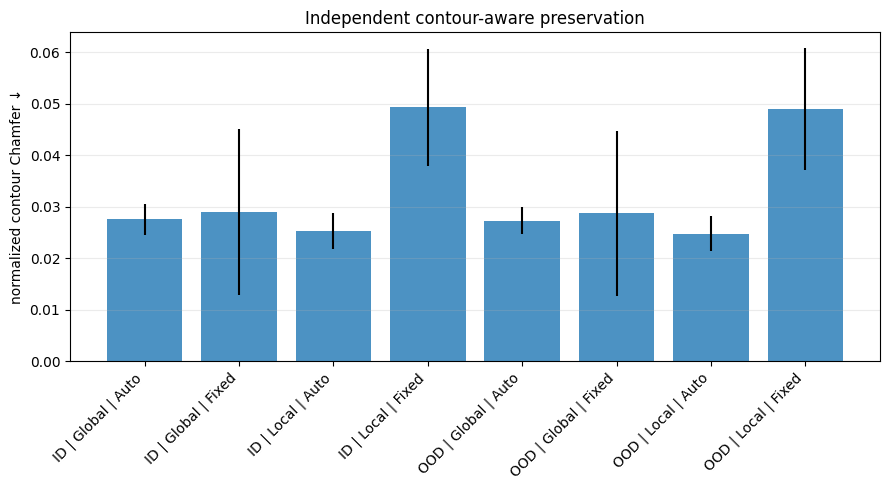

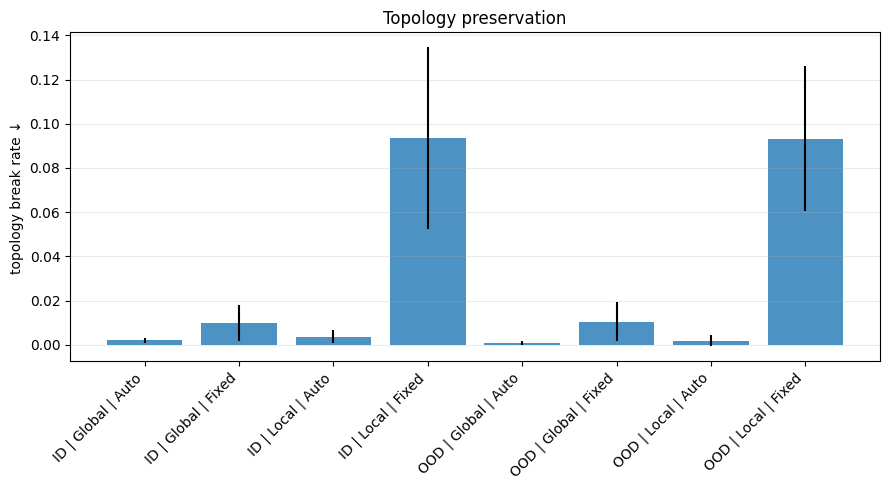

Suggested subsection title:
Independent contour-aware preservation analysis

Files produced:
- C:\Users\Admin\Desktop\Code\Controllable-Latent-Steering-in-VAEs\week11\week11_independent_preservation_outputs\tables\indep_preservation_mean_std.csv
- C:\Users\Admin\Desktop\Code\Controllable-Latent-Steering-in-VAEs\week11\week11_independent_preservation_outputs\tables\indep_preservation_pretty.csv
- C:\Users\Admin\Desktop\Code\Controllable-Latent-Steering-in-VAEs\week11\week11_independent_preservation_outputs\plots\contour_chamfer_mean_std.png
- C:\Users\Admin\Desktop\Code\Controllable-Latent-Steering-in-VAEs\week11\week11_independent_preservation_outputs\plots\topology_break_mean_std.png

Minimal interpretation template:
We add an independent geometric preservation analysis on decoded dSprites images.
For each reconstruction–edit pair, we threshold the image, keep the largest connected component,
remove translation and scale by centroid alignment and area normalization, and compute a symm

In [9]:
# =========================
# Quick plots + paper-facing helper files
# =========================

plot_df = mean_std_summary.copy()
plot_df["label"] = plot_df["split"].str.replace("_test", "", regex=False).str.upper() + " | " + plot_df["family"].str.capitalize() + " | " + plot_df["step_mode"].str.capitalize()

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(plot_df))
ax.bar(x, plot_df["contour_chamfer_norm_mean"], yerr=plot_df["contour_chamfer_norm_std"], alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(plot_df["label"], rotation=45, ha="right")
ax.set_ylabel("normalized contour Chamfer ↓")
ax.set_title("Independent contour-aware preservation")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.savefig(PLOT_ROOT / "contour_chamfer_mean_std.png", dpi=160)
plt.show()

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x, plot_df["topology_break_mean"], yerr=plot_df["topology_break_std"], alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(plot_df["label"], rotation=45, ha="right")
ax.set_ylabel("topology break rate ↓")
ax.set_title("Topology preservation")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.savefig(PLOT_ROOT / "topology_break_mean_std.png", dpi=160)
plt.show()

paper_note = f"""
Suggested subsection title:
Independent contour-aware preservation analysis

Files produced:
- {TABLE_ROOT / 'indep_preservation_mean_std.csv'}
- {TABLE_ROOT / 'indep_preservation_pretty.csv'}
- {PLOT_ROOT / 'contour_chamfer_mean_std.png'}
- {PLOT_ROOT / 'topology_break_mean_std.png'}

Minimal interpretation template:
We add an independent geometric preservation analysis on decoded dSprites images.
For each reconstruction–edit pair, we threshold the image, keep the largest connected component,
remove translation and scale by centroid alignment and area normalization, and compute a symmetric
contour Chamfer distance. We also report principal-axis orientation drift, centroid drift, and topology
break rate. These metrics do not rely on the learned shape head used elsewhere in the paper.
""".strip()

(Path(OUTPUT_ROOT) / "paper_note_independent_preservation.txt").write_text(paper_note, encoding="utf-8")
print(paper_note)